# Response Time Analysis (RTA)

In [134]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.impute import KNNImputer
import scipy.stats as stats
from scipy.stats import levene
import statsmodels
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols

## 1. Importing datasets

In [2]:
url2 = 'https://raw.githubusercontent.com/JeroenGuillierme/Project-MDA/main/Data/'

rta_df = pd.read_csv(
    f'{url2}total_df_with_distances.csv')

# Load Belgium with regions shapefile
belgium_with_provinces_boundary = gpd.read_file(f'{url2}BELGIUM_-_Provinces.geojson')

# Setting the style for the plots
sns.set(style="whitegrid")

## 2. Outlier Detection for Response Time T3-T0

Unsupervised learning method, Isolation forest, used. In this case I only care how the model work on the given dataset, and not on new data. So, data splitting is not performed.

In [3]:
interventions_data = rta_df[rta_df['Intervention'] == 1]
print(interventions_data['T3-T0'].isna().sum())

1965


### 2.1 Visualisation distribution Response Times

[Text(0.5, 1.0, 'Logscale of Response Times'), Text(0.5, 0, 'Log(T3-T0)')]

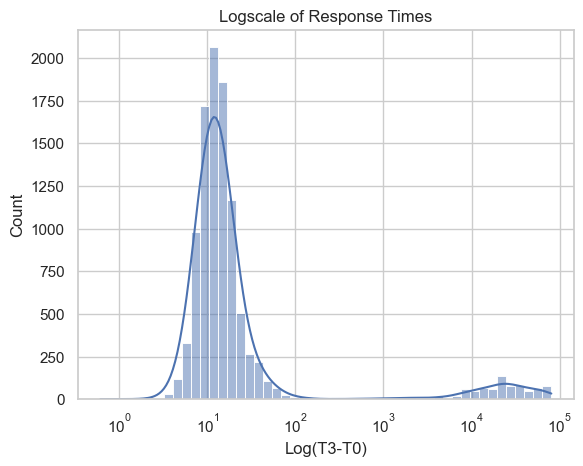

In [4]:
# Plot response times
sns.histplot(data=interventions_data['T3-T0'], bins=50, log_scale=True, kde=True).set(title='Logscale of Response Times', xlabel='Log(T3-T0)') 
# Right-skewed distribution, so log scale was used.

### 2.2 Running Isolation Forest

In [5]:
# Split the DataFrame into two: one with the NaN and one without in the 'T3-T0' column
# DataFrame with NaN values
interventions_data_with_nan = interventions_data[interventions_data['T3-T0'].isna()]  
# DataFrame without NaN values
interventions_data_without_nan = interventions_data[~interventions_data['T3-T0'].isna()]  

print('Without NaN: ', len(interventions_data_without_nan))
print('With NaN: ', len(interventions_data_with_nan))

Without NaN:  10343
With NaN:  1965


In [6]:
Time = interventions_data_without_nan['T3-T0']

# IsolationForest algorithm
IsoFo = IsolationForest(n_estimators=100, contamination='auto',
                        random_state=45)  # Random state added for reproducibility
y_labels = IsoFo.fit_predict(np.array(Time).reshape(-1, 1))

# Only including the inliers
interventions_data_filtered = interventions_data_without_nan[y_labels == 1]  # DataFrame with inliers
discarded_rows = interventions_data_without_nan[y_labels == -1]  # DataFrame with outliers

min_timedelta = discarded_rows['T3-T0'].min()  
max_timedelta = discarded_rows['T3-T0'].max()
min_timedelta2 = interventions_data_filtered['T3-T0'].min()
max_timedelta2 = interventions_data_filtered['T3-T0'].max()
print(f"min response time of outliers: {min_timedelta}") 
print(f"max response time of outliers: {max_timedelta}")
print(f"min response time of inliers: {min_timedelta2}") 
print(f"max response time of inliers: {max_timedelta2}")
print(f"Number of discarded rows: {len(discarded_rows)}")
print(f"Number of filtered rows: {len(interventions_data_filtered)}")


min response time of outliers: 43.78635
max response time of outliers: 80267.83333333333
min response time of inliers: 0.6166666666666667
max response time of inliers: 43.56666666666667
Number of discarded rows: 1047
Number of filtered rows: 9296


In [7]:
print("\nFiltered DataFrame (Inliers):")
interventions_data_filtered.head(5)


Filtered DataFrame (Inliers):


,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province,distance_to_aed,distance_to_ambulance,distance_to_mug,distance_to_pit
0,51.20685,5.13662,1,1.0,18.884917,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen,1.239539,3.523140,8.380098,2.792722
1,51.24848,4.43869,1,1.0,4.238700,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.335321,1.454942,1.259929,2.493499
2,51.24848,4.43869,1,1.0,12.612550,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen,0.335321,1.454942,1.259929,2.493499
3,51.28273,4.42134,1,1.0,13.427900,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen,0.083377,3.262920,3.434839,5.712662
4,51.28273,4.42134,1,1.0,36.619500,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen,0.083377,3.262920,3.434839,5.712662


### 2.3 Total dataset without Response Time outliers

In [8]:
# Add rows with NaN values again:
rta_ready = pd.concat([interventions_data_filtered, interventions_data_with_nan], axis=0)

# Reset index
rta_ready.reset_index(drop=True, inplace=True)

[Text(0.5, 1.0, 'Logscale of Response Times'), Text(0.5, 0, 'Log(T3-T0)')]

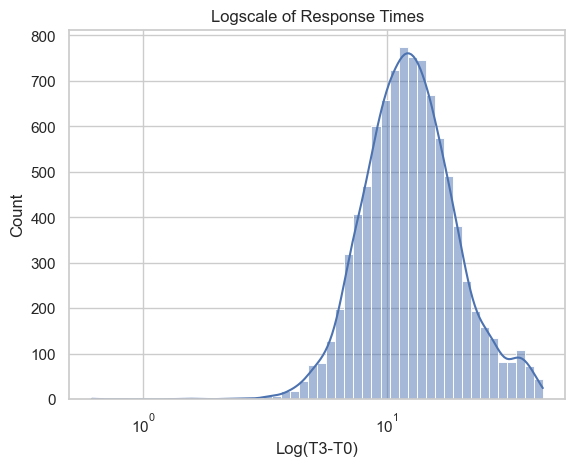

In [9]:
# Plot distribution response times
sns.histplot(data=rta_ready['T3-T0'], bins=50, log_scale=True, kde=True).set(title='Logscale of Response Times', xlabel='Log(T3-T0)') 
# Right-skewed distribution, so log scale was used.

In [10]:
# Last check if no anomalies are left in the dataset

# Get the minimum and maximum values of the 'latitude' column
min_latitude = rta_ready['Latitude'].min()
max_latitude = rta_ready['Latitude'].max()
# Get the minimum and maximum values of the 'longitude' column
min_longitude = rta_ready['Longitude'].min()
max_longitude = rta_ready['Longitude'].max()
# Get the minimum and maximum values of the response time column
min_timedelta = rta_ready['T3-T0'].min()
max_timedelta = rta_ready['T3-T0'].max()

print('Length of dataset: ', len(rta_ready))
print('Number of missing values per column: \n', rta_ready.isna().sum())
print('Number of missing values per column: \n', discarded_rows.isna().sum())

print('Number of outliers/anomalies detected: ', len(discarded_rows))
print('Number of inliers: ', len(rta_ready))

print(f"Minimum latitude of dataset: {min_latitude}")
print(f"Maximum latitude of dataset: {max_latitude}")
print(f"Minimum longitude of dataset: {min_longitude}")
print(f"Maximum longitude of dataset: {max_longitude}")
print(f"min_timedelta of dataset: {min_timedelta}")
print(f"max_timedelta of dataset: {max_timedelta}")  

Length of dataset:  11261
Number of missing values per column: 
 Latitude                    0
Longitude                   0
Intervention                0
Eventlevel                  0
T3-T0                    1965
EventType                   0
Vector type                80
AED                         0
Ambulance                   0
Mug                         0
PIT                         0
Province                   26
distance_to_aed             0
distance_to_ambulance       0
distance_to_mug             0
distance_to_pit             0
dtype: int64
Number of missing values per column: 
 Latitude                 0
Longitude                0
Intervention             0
Eventlevel               0
T3-T0                    0
EventType                0
Vector type              0
AED                      0
Ambulance                0
Mug                      0
PIT                      0
Province                 3
distance_to_aed          0
distance_to_ambulance    0
distance_to_mug          

The Isolation Forest algorithm indicated every intervention with a response time longer than 43.5 minutes as an outlier/anomaly.

### 2.4 Visualisation coordinates of intervention locations with outlying Response Time

Most of the interventions with outlying Response Times are found in West-Vlaanderen and Vlaams Brabant.

<Axes: xlabel='Longitude', ylabel='Latitude'>

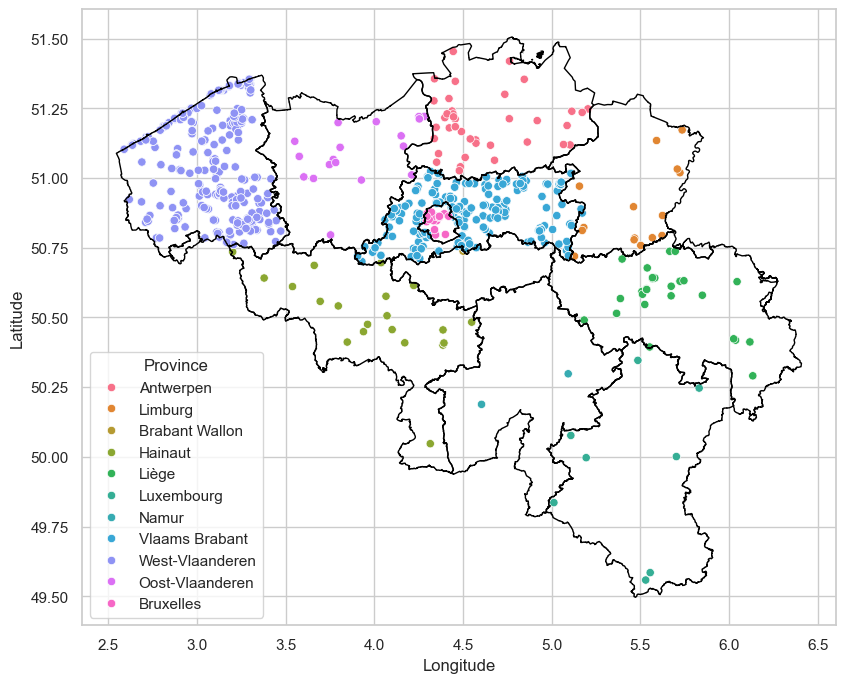

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=discarded_rows, x= 'Longitude', y='Latitude', hue='Province', ax=ax)
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

### 2.5 Visualisation coordinates of intervention locations with inlying Response Times

<Axes: xlabel='Longitude', ylabel='Latitude'>

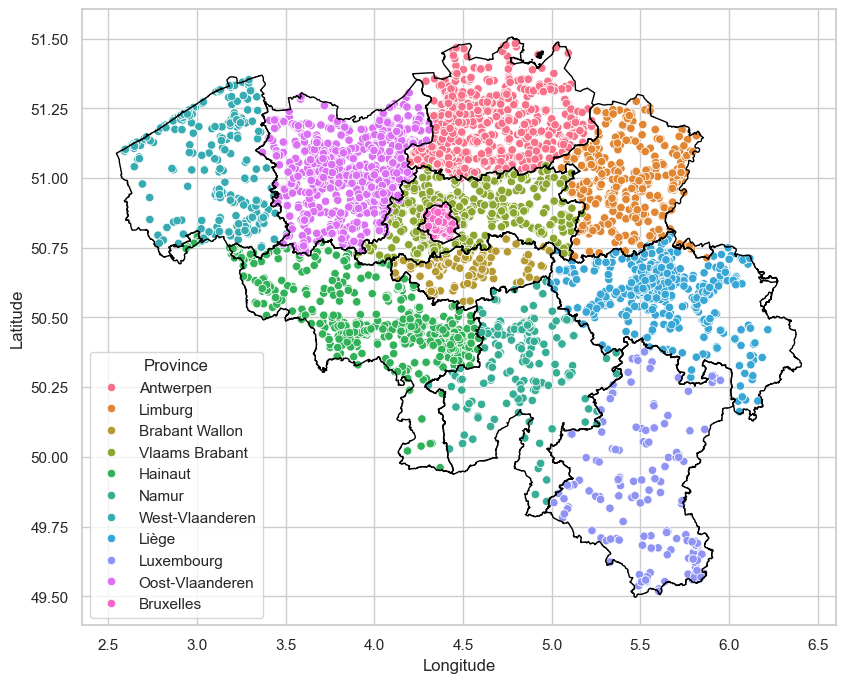

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=interventions_data_filtered, x= 'Longitude', y='Latitude', hue='Province', ax=ax)
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

## 3. Imputing missing Response Times

### 3.1 Visualisation coordinates of intervention locations with no reported Response Times

The dataset is missing  1965 Response Times


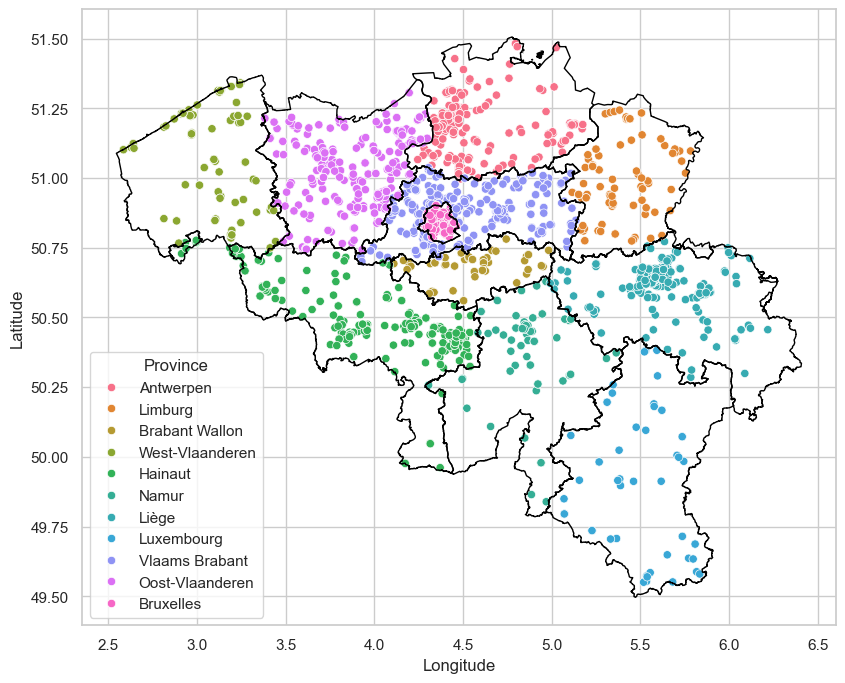

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=interventions_data_with_nan, x= 'Longitude', y='Latitude', hue='Province', ax=ax)
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

print('The dataset is missing ', len(interventions_data_with_nan), 'Response Times')

### 3.2 Replacing Missing Response Times with (KNN) Imputed values Based On Location and Distances
Assign Response Times to intervention locations with no reported Response Time in the dataset using KNN Imputer.

* Feature Selection: Selected Latitude, Longitude,T3-T0 and the calculated distances for imputation. 
* Scaling: No scaling was done whatsoever because the imputed values shouldn’t be affected by scaling, because sometimes extreme values should have an effect on the response time on a certain location. And outlying response times have been removed already.
* KNN Imputation: KNN Imputer applied to the data to fill in the missing values. Again no train and test set was created because it should only work on given dataset and not on new data. This method of imputation uses the k-Nearest Neighbors approach. By default, a euclidean distance metric that supports missing values, is used to find the nearest neighbors. e.rame.

In [14]:
# Select features for imputation
features_for_imputation = rta_ready[['Latitude', 'Longitude', 'distance_to_ambulance',
                                              'distance_to_mug', 'distance_to_pit', 'T3-T0']]

print('Missing values:\n', features_for_imputation.isna().sum())
features_for_imputation.head(3)

Missing values:
 Latitude                    0
Longitude                   0
distance_to_ambulance       0
distance_to_mug             0
distance_to_pit             0
T3-T0                    1965
dtype: int64


,Latitude,Longitude,distance_to_ambulance,distance_to_mug,distance_to_pit,T3-T0
0,51.20685,5.13662,3.523140,8.380098,2.792722,18.884917
1,51.24848,4.43869,1.454942,1.259929,2.493499,4.238700
2,51.24848,4.43869,1.454942,1.259929,2.493499,12.612550


In [15]:
# set seed for allowing multiple runs with same outcome
np.random.seed(42)

# Initialize the KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5)

# Perform KNN Imputation
imputed_values = knn_imputer.fit_transform(features_for_imputation)

# Create a dataframe with the imputed values
imputed_data = pd.DataFrame(imputed_values, columns=['Latitude', 'Longitude', 'distance_to_ambulance',
                                                     'distance_to_mug', 'distance_to_pit', 'T3-T0'])

print('Missing values: \n', imputed_data.isna().sum())
print(len(imputed_data))
imputed_data.head(3)

Missing values: 
 Latitude                 0
Longitude                0
distance_to_ambulance    0
distance_to_mug          0
distance_to_pit          0
T3-T0                    0
dtype: int64
11261


,Latitude,Longitude,distance_to_ambulance,distance_to_mug,distance_to_pit,T3-T0
0,51.20685,5.13662,3.523140,8.380098,2.792722,18.884917
1,51.24848,4.43869,1.454942,1.259929,2.493499,4.238700
2,51.24848,4.43869,1.454942,1.259929,2.493499,12.612550


### 3.3 Assigning imputed Response Times back to original dataframe

In [16]:
rta_ready.loc[:,'T3-T0'] = imputed_data['T3-T0']
print('Missing values: \n', rta_ready.isna().sum())

Missing values: 
 Latitude                  0
Longitude                 0
Intervention              0
Eventlevel                0
T3-T0                     0
EventType                 0
Vector type              80
AED                       0
Ambulance                 0
Mug                       0
PIT                       0
Province                 26
distance_to_aed           0
distance_to_ambulance     0
distance_to_mug           0
distance_to_pit           0
dtype: int64


### 3.4 Visualisation distribution imputed Response Times

[Text(0.5, 1.0, 'Logscale of Imputed Response Times'),
 Text(0.5, 0, 'Log(T3-T0)')]

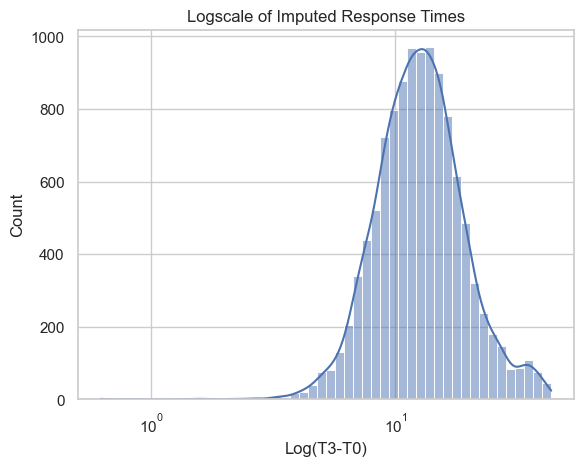

In [17]:
# Plot response times
sns.histplot(data=rta_ready['T3-T0'], bins=50, log_scale=True, kde=True).set(title='Logscale of Imputed Response Times', xlabel='Log10(T3-T0)') 
# Right-skewed distribution, so log scale was used.

<Axes: xlabel='Longitude', ylabel='Latitude'>

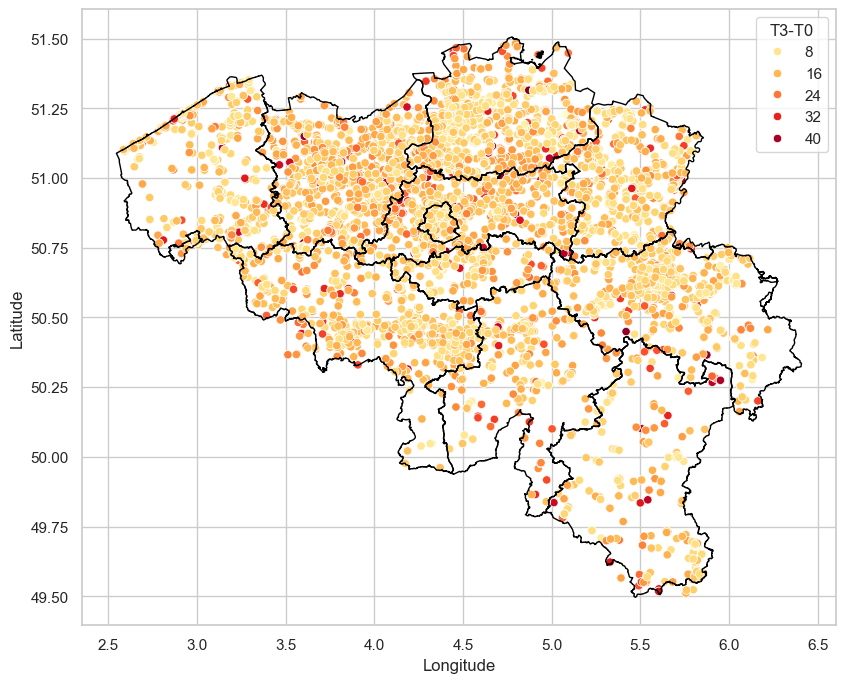

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=rta_ready, x= 'Longitude', y='Latitude', hue='T3-T0', palette='YlOrRd', ax=ax)
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

## 4. Split up Response Times in three categories: Short, Medium and Long 

According to the literature, the ambulance response time is divided into 3 categories:
short (<4 min), medium (4-8 min), and long (>8 min). 
If the accident is in a multi-store building, this time will include some additional time called vertical response time. 
Vertical response time includes time interval from arrival on-scene to arrival at the patient's side.
Although shorter ambulance response time can increase medical effectiveness and satisfaction, 
it may reduce productivity due to the resources required and increased costs.

(link: https://www.researchgate.net/publication/362523045_Assessment_of_Ambulance_Response_Time_A_Study_of_Tabriz_Emergency_Medical_Center_Tabriz_City_Iran/fulltext/62fbbc80e3c7de4c34605bf1/Assessment-of-Ambulance-Response-Time-A-Study-of-Tabriz-Emergency-Medical-Center-Tabriz-City-Iran.pdf?origin=scientificContributions ).

In [19]:
# Create new column RT_category conatining the three categories

# Initialize the RT_category column with an empty string
rta_ready['RT_category'] = ''

# Apply the categorization
rta_ready.loc[rta_ready['T3-T0'] < 4, 'RT_category'] = 'Short (<4 min)'
rta_ready.loc[(rta_ready['T3-T0'] >= 4) & (rta_ready['T3-T0'] <= 8), 'RT_category'] = 'Medium (4-8 min)'
rta_ready.loc[rta_ready['T3-T0'] > 8, 'RT_category'] = 'Long (>8 min)'

imputed_data.head(3)

,Latitude,Longitude,distance_to_ambulance,distance_to_mug,distance_to_pit,T3-T0
0,51.20685,5.13662,3.523140,8.380098,2.792722,18.884917
1,51.24848,4.43869,1.454942,1.259929,2.493499,4.238700
2,51.24848,4.43869,1.454942,1.259929,2.493499,12.612550


In [20]:
rta_ready[rta_ready['RT_category'] == '']

,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province,distance_to_aed,distance_to_ambulance,distance_to_mug,distance_to_pit,RT_category


In [21]:
# Create a table counting the number of interventions per Response Time category

counts = rta_ready.loc[:,'RT_category'].value_counts
pd.merge(counts(normalize=False), counts(normalize=True), left_index=True, right_index=True)

,count,proportion
RT_category,,
Long (>8 min),9834,0.873279
Medium (4-8 min),1384,0.122902
Short (<4 min),43,0.003818


## 5. Comparing Response Times between different groups

In [85]:
# Renaming some variables for performing ANOVA
rta_anova = rta_ready
rta_anova['response_time'] = rta_anova['T3-T0']
rta_anova['vector_type'] = rta_anova['Vector type']

print('Missing values: \n', rta_anova.isna().sum())

Missing values: 
 Latitude                  0
Longitude                 0
Intervention              0
Eventlevel                0
T3-T0                     0
EventType                 0
Vector type              80
AED                       0
Ambulance                 0
Mug                       0
PIT                       0
Province                 26
distance_to_aed           0
distance_to_ambulance     0
distance_to_mug           0
distance_to_pit           0
RT_category               0
response_time             0
vector_type              80
dtype: int64


### 5.1 Response Time versus Vector type (Ambulance, MUG or PIT)

#### 5.1.1 Summary Statistics & Visualisation

In [171]:
# Discard rows with Missing Values for vector type
rta_anova_vt = rta_anova[['response_time', 'vector_type']].dropna()
rta_anova_vt.reset_index(drop=True, inplace=True) # Reset index after dropping missing values

# Log-Transform the variable Response Time, because is right-skewed
rta_anova_vt['log_response_time'] = np.nan # Initialize new column for transformed response times
rta_anova_vt.loc[:,'log_response_time'] = np.log10(rta_anova_vt['response_time'])

print(len(rta_anova),len(rta_anova_vt)) # 80 observations with missing vector type removed

11261 11181


In [172]:
# Basics Statistics per Group
rta_anova_vt.groupby('vector_type')['response_time'].describe()

,count,mean,std,min,25%,50%,75%,max
vector_type,,,,,,,,
Ambulance,5562.0,13.206233,6.127775,0.616667,9.149513,11.920350,15.482279,43.566667
MUG,5237.0,14.450056,6.229776,0.616667,10.233333,13.275667,17.003333,43.566667
PIT,382.0,13.247846,5.865935,1.320917,9.132363,12.033333,16.379167,41.600000


Text(0, 0.5, 'Response Time')

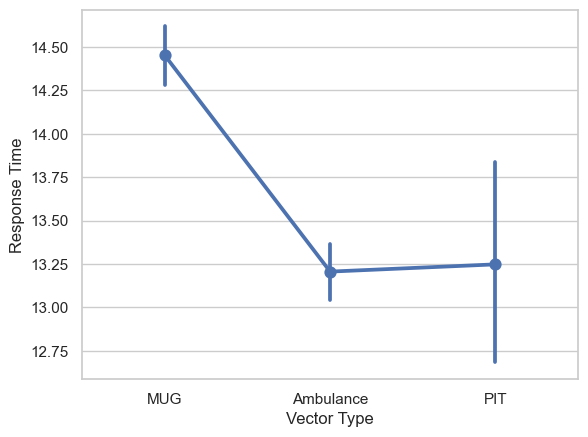

In [181]:
sns.pointplot(x='vector_type', y = 'response_time', data = rta_anova_vt) # errorbars: 95% confidence interval
plt.xlabel('Vector Type')
plt.ylabel('Response Time')

#### 5.1.2 Perform Analysis

In [168]:
# ANOVA
formula1 = 'log_response_time ~ vector_type'
model1 = ols(formula1, data=rta_anova_vt).fit()
anova_table1 = sm.stats.anova_lm(model1, typ=2)
anova_table1

,sum_sq,df,F,PR(>F)
vector_type,27.713080,2.0,80.67303,1.639076e-35
Residual,1919.952698,11178.0,NaN,NaN


group1,group2,meandiff,p-adj,lower,upper,reject
Ambulance,MUG,0.0435,0.0,0.0353,0.0516,True
Ambulance,PIT,0.0022,0.9702,-0.0201,0.0245,False
MUG,PIT,-0.0412,0.0,-0.0636,-0.0189,True


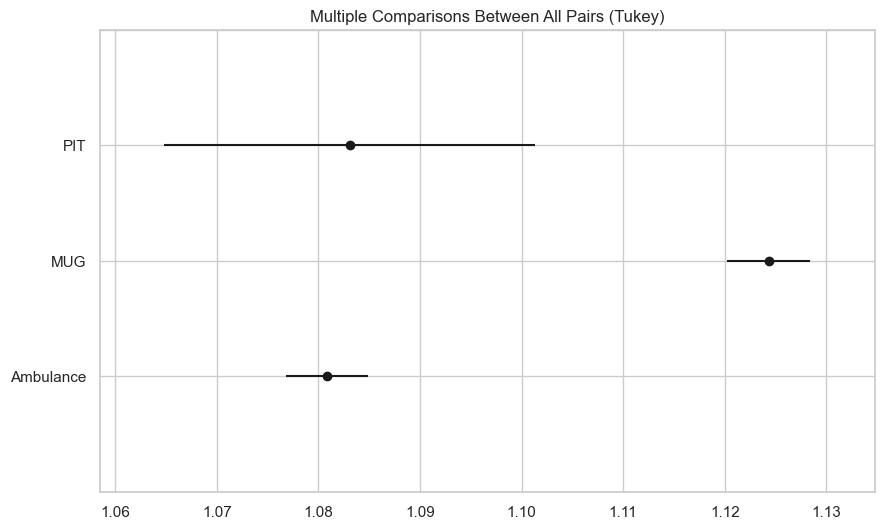

In [212]:
# Post-hoc test if ANOVA is significant
# Tukey's honestly significantly differneced (HSD) test
# H0: No significant difference between the means of two groups
if anova_table1['PR(>F)'].iloc[0] < 0.05:
    tukey1 = pairwise_tukeyhsd(rta_anova_vt['log_response_time'], rta_anova_vt['vector_type'], alpha=0.05)

# Plot group confidence intervals
tukey1.plot_simultaneous()    

tukey1.summary()

#### 5.1.3 Checking Model Assumptions

**Assumptions of ANOVA**
The ANOVA test has important assumptions that must be satisfied in order for the associated p-value to be valid.
* The samples are independent.
* Each sample is from a normally distributed population.
* The population standard deviations of the groups are all equal. This property is known as homoscedasticity.

**Normality Of Residuals**

Seems like normailty is mostly violated in the tails of the distribution.

C:\Users\Admin\Documents\MDA 2de zit\MDA24\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11181.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk Test: p-value = 3.9283302736267734e-26
Residuals do not appear to be normally distributed (reject H0).


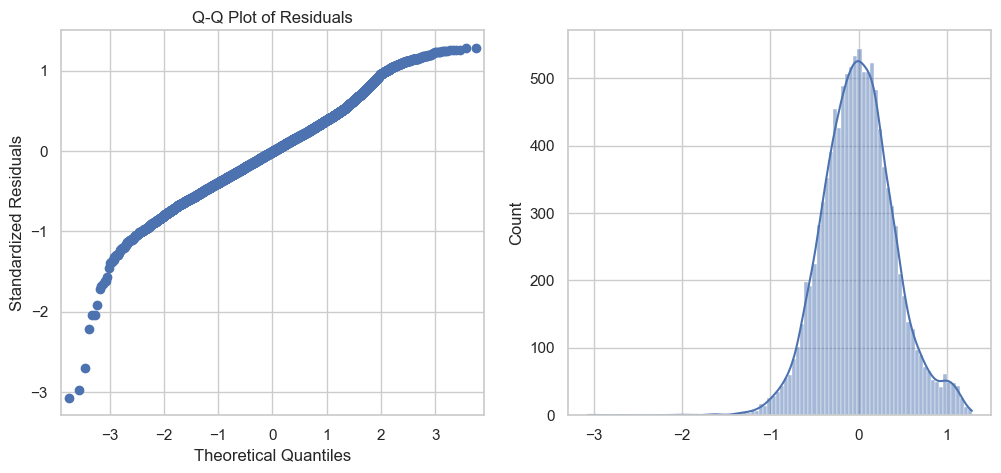

In [236]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normality of residuals with QQ-plot
residuals1 = model1.resid
sm.qqplot(residuals1, ax=axes[0])
axes[0].set_title('Q-Q Plot of Residuals')
axes[0].set_xlabel("Theoretical Quantiles")
axes[0].set_ylabel("Standardized Residuals")

# Histogram
sns.histplot(residuals1, kde=True, ax=axes[1], log_scale=False)

# Shapiro-Wilk Test
shapiro_test1 = stats.shapiro(residuals1)
print('Shapiro-Wilk Test: p-value =', shapiro_test1.pvalue)

# Interpret the result
if shapiro_test1.pvalue > 0.05:
    print("Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("Residuals do not appear to be normally distributed (reject H0).")

**Homogeneity Of Variances**

p-value of the levene test:  0.004202171682258098
Variances across groups are not equal (reject H0).


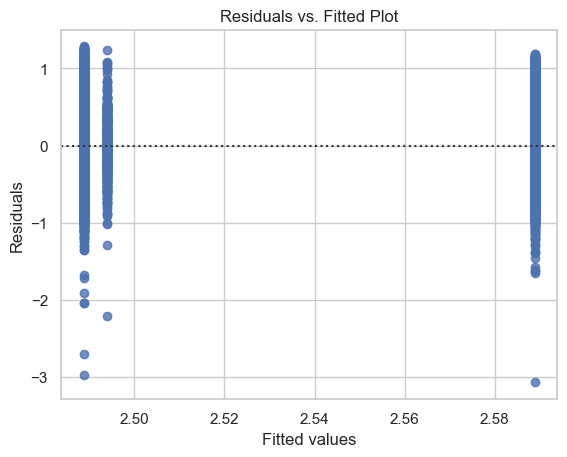

In [190]:
# Residuals vs Fitted Plot
fitted_vals1 = model1.fittedvalues
sns.residplot(x=fitted_vals1, y=residuals1, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Plot')


# Levene's test
# H0: population variances across groups are eaqual
levene_test1 = levene(rta_anova_vt['log_response_time'][rta_anova_vt['vector_type'] == 'Ambulance'],
                     rta_anova_vt['log_response_time'][rta_anova_vt['vector_type'] == 'MUG'],
                     rta_anova_vt['log_response_time'][rta_anova_vt['vector_type'] == 'PIT'])
print('p-value of the levene test: ', levene_test1[1])
# Interpret the result
if levene_test1.pvalue > 0.05:
    print("Variances across groups are equal (fail to reject H0).")
else:
    print("Variances across groups are not equal (reject H0).")

### 5.2 Response Time versus Province

#### 5.2.1 Summary Statistics & Visualisation

In [174]:
# Discard rows with Missing Values for vector type
rta_anova_prov = rta_anova[['response_time', 'Province']].dropna()
rta_anova_prov.reset_index(drop=True, inplace=True) # Reset index after dropping missing values

# Log-Transform the variable Response Time, because is right-skewed
rta_anova_prov['log_response_time'] = np.nan # Initialize new column for transformed response times
rta_anova_prov.loc[:,'log_response_time'] = np.log10(rta_anova_prov['response_time'])

print(len(rta_anova),len(rta_anova_prov)) # 26 observations with missing province removed

11261 11235


In [183]:
# Basics Statistics per Group
rta_anova_prov.groupby('Province')['response_time'].describe()

,count,mean,std,min,25%,50%,75%,max
Province,,,,,,,,
Antwerpen,2245.0,12.352694,5.927785,1.320917,8.580900,11.042137,14.238617,43.254500
Brabant Wallon,244.0,13.765225,6.166539,4.002150,9.559800,12.357125,16.177225,39.465983
Bruxelles,618.0,12.555081,5.838849,2.167375,9.159086,11.085307,13.995171,42.837061
Hainaut,1230.0,13.474580,5.167386,2.253300,9.953126,12.561000,15.821592,39.439900
Limburg,839.0,13.085769,5.675511,1.572733,9.272008,12.089287,15.436367,40.902767
Liège,1360.0,12.547670,5.306695,0.809817,9.028854,11.548858,14.871742,42.613933
Luxembourg,347.0,14.511265,7.246214,4.052067,9.262367,12.927400,17.844575,39.883517
Namur,434.0,14.058200,6.137928,3.116183,9.701183,12.827983,17.009586,38.256833
Oost-Vlaanderen,2154.0,14.928801,6.422794,3.333333,10.470833,13.733333,17.745833,42.050000


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Antwerpen'),
  Text(1, 0, 'Limburg'),
  Text(2, 0, 'Brabant Wallon'),
  Text(3, 0, 'Vlaams Brabant'),
  Text(4, 0, 'Hainaut'),
  Text(5, 0, 'Namur'),
  Text(6, 0, 'West-Vlaanderen'),
  Text(7, 0, 'Liège'),
  Text(8, 0, 'Luxembourg'),
  Text(9, 0, 'Oost-Vlaanderen'),
  Text(10, 0, 'Bruxelles')])

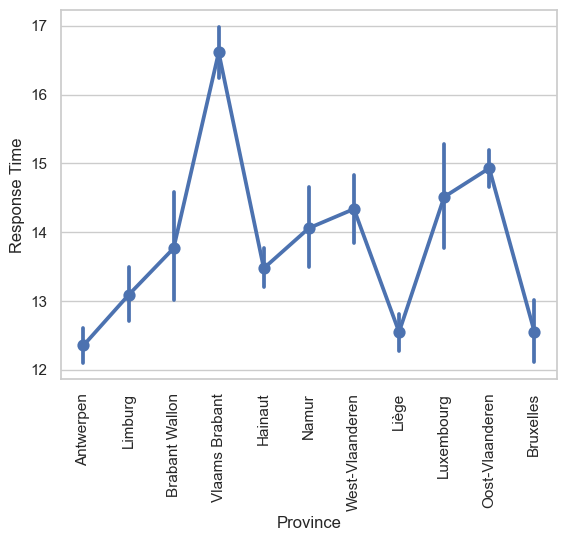

In [185]:
sns.pointplot(x='Province', y = 'response_time', data = rta_anova_prov) # errorbars: 95% confidence interval
plt.ylabel('Response Time')
plt.xticks(rotation=90)

#### 5.2.2 Perform Analysis

In [187]:
# ANOVA
formula2 = 'log_response_time ~ Province'
model2 = ols(formula2, data=rta_anova_prov).fit()
anova_table2 = sm.stats.anova_lm(model2, typ=2)
anova_table2

,sum_sq,df,F,PR(>F)
Province,20.540219,10.0,66.47564,2.373554e-132
Residual,346.808873,11224.0,NaN,NaN


group1,group2,meandiff,p-adj,lower,upper,reject
Antwerpen,Brabant Wallon,0.0492,0.0016,0.0111,0.0874,True
Antwerpen,Bruxelles,0.0128,0.8808,-0.0129,0.0385,False
Antwerpen,Hainaut,0.0495,0.0,0.0295,0.0696,True
Antwerpen,Limburg,0.0301,0.0012,0.0072,0.053,True
Antwerpen,Liège,0.0141,0.4082,-0.0053,0.0336,False
Antwerpen,Luxembourg,0.0616,0.0,0.029,0.0943,True
Antwerpen,Namur,0.058,0.0,0.0283,0.0876,True
Antwerpen,Oost-Vlaanderen,0.088,0.0,0.071,0.1051,True
Antwerpen,Vlaams Brabant,0.1365,0.0,0.1159,0.1571,True
Antwerpen,West-Vlaanderen,0.0702,0.0,0.0445,0.0958,True


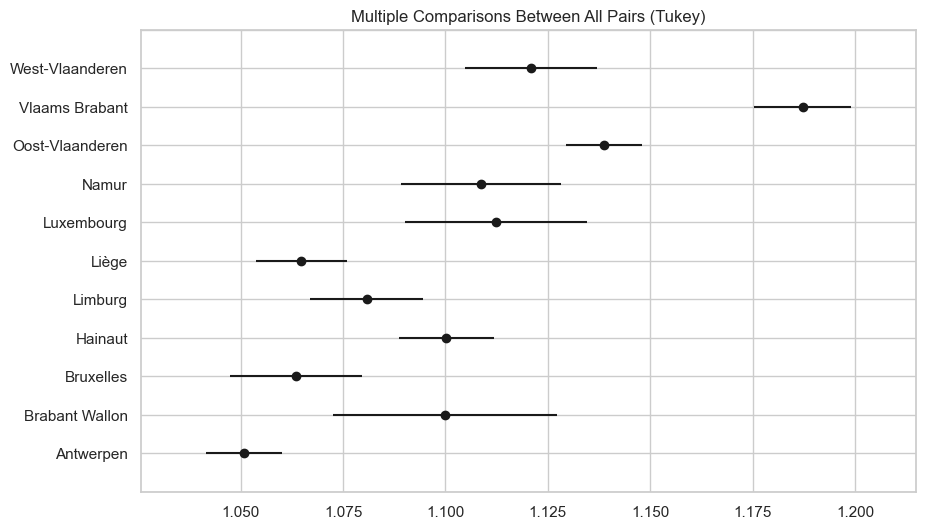

In [214]:
# Post-hoc test if ANOVA is significant
# Tukey's honestly significantly differneced (HSD) test
# H0: No significant difference between the means of two groups
if anova_table2['PR(>F)'].iloc[0] < 0.05:
    tukey2 = pairwise_tukeyhsd(rta_anova_prov['log_response_time'], rta_anova_prov['Province'], alpha=0.05)

# Plot group confidence intervals
tukey2.plot_simultaneous()    

tukey2.summary()

#### 5.2.3 Checking Model Assumptions

**Normality Of Residuals**

C:\Users\Admin\Documents\MDA 2de zit\MDA24\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11235.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk Test: p-value = 1.8514815714635383e-28
Residuals do not appear to be normally distributed (reject H0).


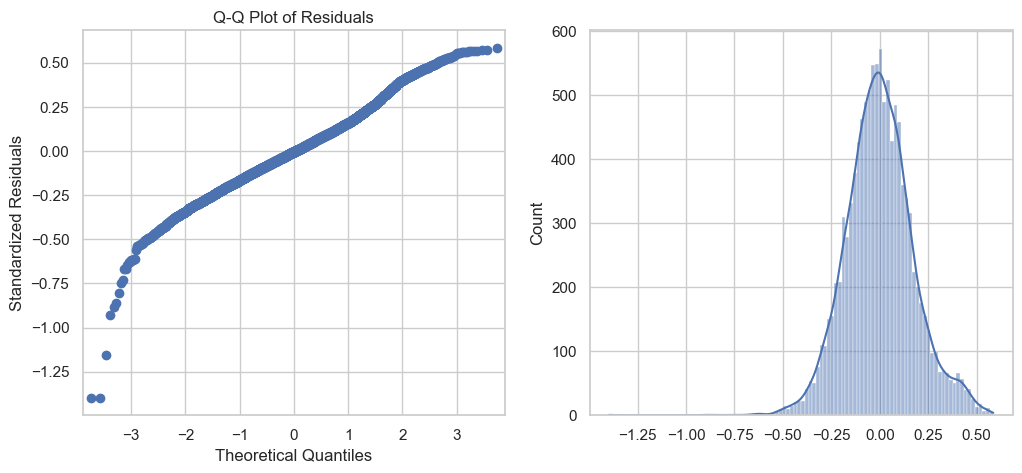

In [237]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normality of residuals with QQ-plot
residuals2 = model2.resid
sm.qqplot(residuals2, ax=axes[0])
axes[0].set_title('Q-Q Plot of Residuals')
axes[0].set_xlabel("Theoretical Quantiles")
axes[0].set_ylabel("Standardized Residuals")

# Histogram
sns.histplot(residuals2, kde=True, ax=axes[1])

# Shapiro-Wilk Test
shapiro_test2 = stats.shapiro(residuals2)
print('Shapiro-Wilk Test: p-value =', shapiro_test2.pvalue)

# Interpret the result
if shapiro_test2.pvalue > 0.05:
    print("Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("Residuals do not appear to be normally distributed (reject H0).")

**Homogeneity Of Variances**

p-value of the levene test:  5.766548910646793e-17
Variances across groups are not equal (reject H0).


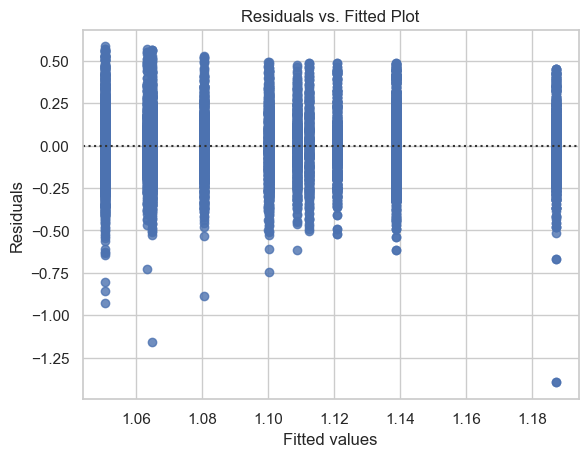

In [193]:
# Residuals vs Fitted Plot
fitted_vals2 = model2.fittedvalues
sns.residplot(x=fitted_vals2, y=residuals2, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Plot')


# Levene's test
# H0: population variances across groups are eaqual
levene_test2 = levene(rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Antwerpen'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Limburg'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Brabant Wallon'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Vlaams Brabant'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'West-Vlaanderen'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Hainaut'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Namur'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Liège'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Luxembourg'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Oost-Vlaanderen'],
                     rta_anova_prov['log_response_time'][rta_anova_prov['Province'] == 'Bruxelles'])
print('p-value of the levene test: ', levene_test2[1])
# Interpret the result
if levene_test2.pvalue > 0.05:
    print("Variances across groups are equal (fail to reject H0).")
else:
    print("Variances across groups are not equal (reject H0).")

### 5.3 Response Time versus Event Level

#### 5.3.1 Summary Statistics & Visualisation

In [216]:
# Discard rows with Missing Values for vector type
rta_anova_el = rta_anova[['response_time', 'Eventlevel']].dropna()
rta_anova_el.reset_index(drop=True, inplace=True) # Reset index after dropping missing values

# Make Event level categorical
rta_anova_el['Eventlevel'] = rta_anova_el['Eventlevel'].astype('category')

# Log-Transform the variable Response Time, because is right-skewed
rta_anova_el['log_response_time'] = np.nan # Initialize new column for transformed response times
rta_anova_el.loc[:,'log_response_time'] = np.log10(rta_anova_el['response_time'])

print(len(rta_anova),len(rta_anova_el)) # 0 observations with missing province removed

11261 11261


In [223]:
# Basics Statistics per Group
rta_ready.groupby('Eventlevel')['response_time'].describe()

,count,mean,std,min,25%,50%,75%,max
Eventlevel,,,,,,,,
0.0,1556.0,12.341187,5.567193,1.572733,8.712742,11.169783,14.528829,41.248764
1.0,8148.0,14.064282,6.310335,0.616667,9.862725,12.798467,16.616940,43.566667
2.0,606.0,13.322883,5.636685,1.556450,9.484958,12.419183,15.561778,42.604350
5.0,887.0,13.777289,5.978246,2.253300,9.660200,12.600000,16.360783,42.837061
6.0,59.0,15.658044,6.567550,2.631367,10.936667,14.553333,19.250013,36.973533
7.0,5.0,20.090010,1.772889,18.218717,18.962533,20.163583,20.226750,22.878467


Text(0, 0.5, 'Response Time')

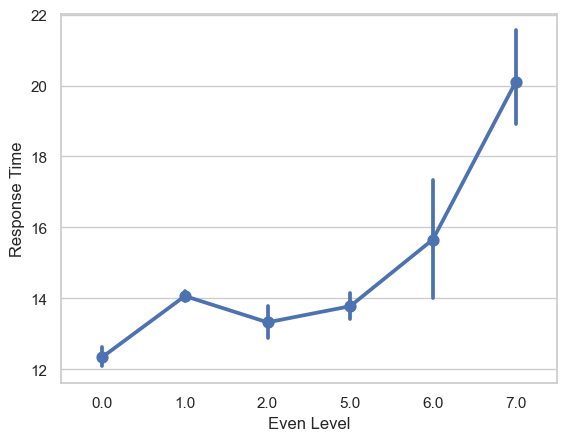

In [224]:
sns.pointplot(x='Eventlevel', y = 'response_time', data = rta_ready) # errorbars: 95% confidence interval
plt.xlabel('Even Level')
plt.ylabel('Response Time')

#### 5.3.2 Perform Analysis

In [225]:
# ANOVA
formula3 = 'log_response_time ~ Eventlevel'
model3 = ols(formula3, data=rta_anova_el).fit()
anova_table3 = sm.stats.anova_lm(model3, typ=2)
anova_table3

,sum_sq,df,F,PR(>F)
Eventlevel,4.560577,5.0,28.224122,1.573988e-28
Residual,363.726401,11255.0,NaN,NaN


group1,group2,meandiff,p-adj,lower,upper,reject
0.0,1.0,0.0558,0.0,0.0416,0.07,True
0.0,2.0,0.0348,0.0007,0.0103,0.0593,True
0.0,5.0,0.0491,0.0,0.0276,0.0707,True
0.0,6.0,0.1047,0.0002,0.0367,0.1726,True
0.0,7.0,0.2475,0.0258,0.018,0.477,True
1.0,2.0,-0.021,0.0617,-0.0426,0.0006,False
1.0,5.0,-0.0067,0.9004,-0.0248,0.0114,False
1.0,6.0,0.0488,0.2981,-0.0181,0.1158,False
1.0,7.0,0.1917,0.162,-0.0375,0.4209,False
2.0,5.0,0.0143,0.6571,-0.0127,0.0413,False


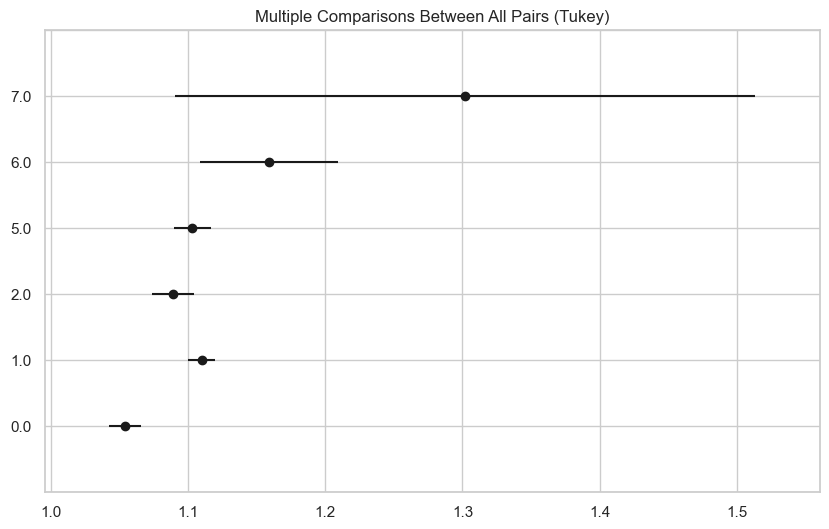

In [226]:
# Post-hoc test if ANOVA is significant
# Tukey's honestly significantly differneced (HSD) test
# H0: No significant difference between the means of two groups
if anova_table3['PR(>F)'].iloc[0] < 0.05:
    tukey3 = pairwise_tukeyhsd(rta_anova_el['log_response_time'], rta_anova_el['Eventlevel'], alpha=0.05)

# Plot group confidence intervals
tukey3.plot_simultaneous()    

tukey3.summary()

#### 5.3.3 Checking Model Assumptions

**Normality Of Residuals**

C:\Users\Admin\Documents\MDA 2de zit\MDA24\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11261.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk Test: p-value = 2.385952444723327e-26
Residuals do not appear to be normally distributed (reject H0).


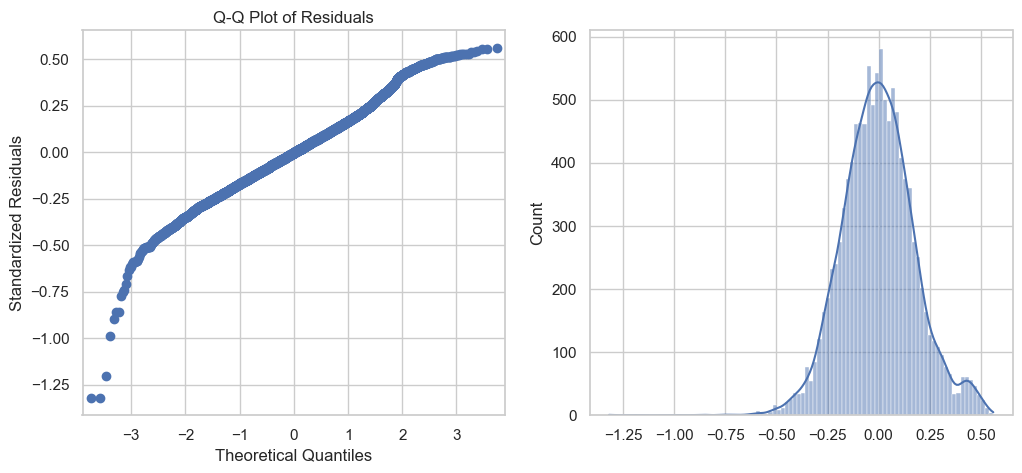

In [238]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normality of residuals with QQ-plot
residuals3 = model3.resid
sm.qqplot(residuals3, ax=axes[0])
axes[0].set_title('Q-Q Plot of Residuals')
axes[0].set_xlabel("Theoretical Quantiles")
axes[0].set_ylabel("Standardized Residuals")

# Histogram
sns.histplot(residuals3, kde=True, ax=axes[1])

# Shapiro-Wilk Test
shapiro_test3 = stats.shapiro(residuals3)
print('Shapiro-Wilk Test: p-value =', shapiro_test3.pvalue)

# Interpret the result
if shapiro_test3.pvalue > 0.05:
    print("Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("Residuals do not appear to be normally distributed (reject H0).")

**Homogeneity Of Variances**

p-value of the levene test:  0.2739184477860927
Variances across groups are equal (fail to reject H0).


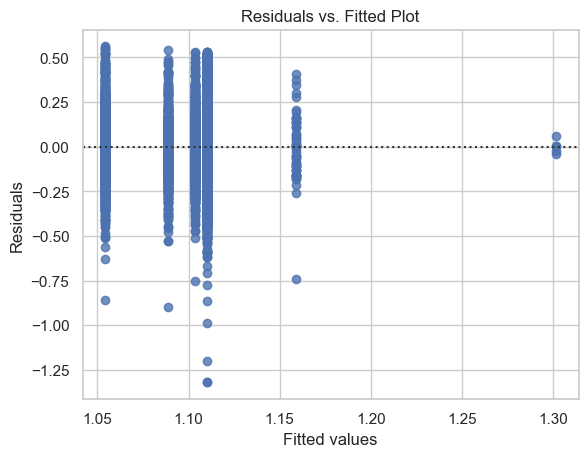

In [231]:
# Residuals vs Fitted Plot
fitted_vals3 = model3.fittedvalues
sns.residplot(x=fitted_vals3, y=residuals3, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Plot')


# Levene's test
# H0: population variances across groups are eaqual
levene_test3 = levene(rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 0.0],
                      rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 1.0],
                      rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 2.0],
                      rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 5.0],
                      rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 6.0],
                      rta_anova_el['log_response_time'][rta_anova_el['Eventlevel'] == 7.0])
print('p-value of the levene test: ', levene_test3[1])
# Interpret the result
if levene_test3.pvalue > 0.05:
    print("Variances across groups are equal (fail to reject H0).")
else:
    print("Variances across groups are not equal (reject H0).")